Files created:
gev_data1_param1.csv
gev_data2_param2.csv


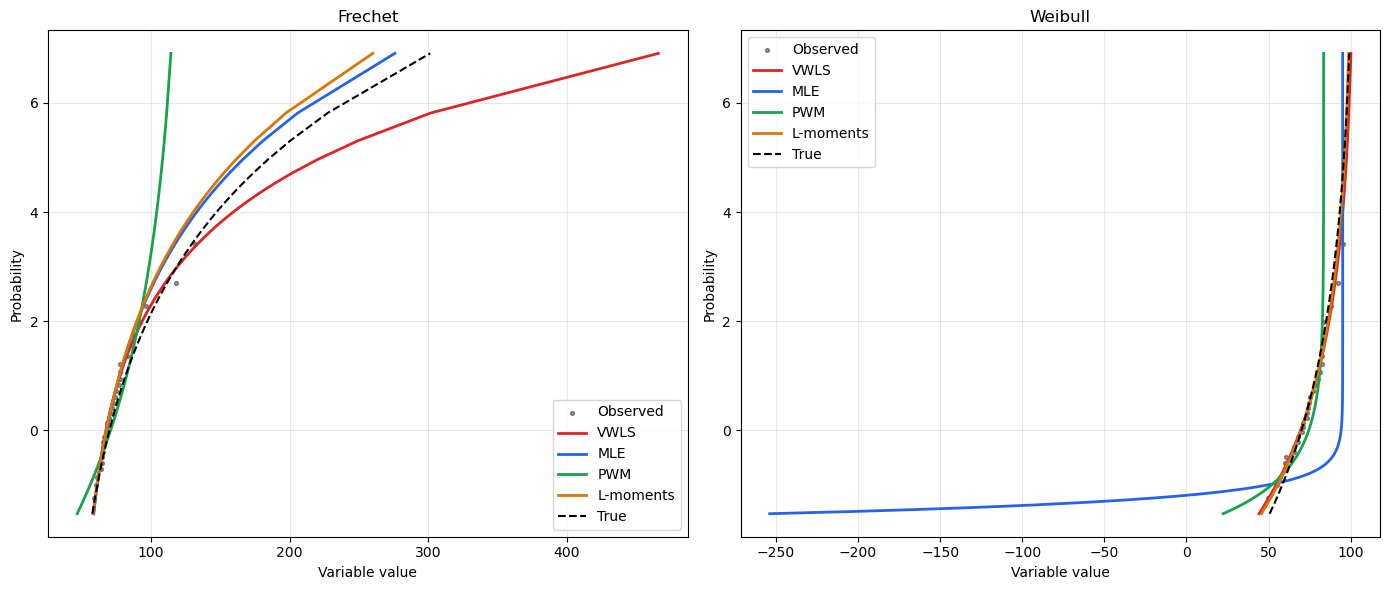

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import genextreme
from scipy.special import gamma as gamma_func
from math import factorial
import pandas as pd

# Generated Data

N = 30

# Dataset 1: Frechet
mu    = 70
alpha = 10
gamma = 0.3
data1 = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N, random_state=42)

# Dataset 2: Weibull
mu    = 70
alpha = 10
gamma = -0.3
data2 = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N, random_state=99)

pd.DataFrame(data1, columns=["value"]).to_csv("gev_data1_param1.csv", index=False)
pd.DataFrame(data2, columns=["value"]).to_csv("gev_data2_param2.csv", index=False)

print("Files created:")
print("gev_data1_param1.csv")
print("gev_data2_param2.csv")


# Load Data
df1   = pd.read_csv('gev_data1_param1.csv')
df2   = pd.read_csv('gev_data2_param2.csv')

data1 = df1['value'].values
data2 = df2['value'].values



# Hepler Functions

def weibull_plotting_positions(n):
    ranks = np.arange(1, n + 1)
    P = ranks / (n + 1)
    return P


def gev_pdf(x, mu, alpha, gamma):

    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return (1.0 / alpha) * np.exp(-y) * np.exp(-np.exp(-y))

    inner = 1.0 + gamma * (x - mu) / alpha
    inner = np.maximum(inner, 1e-12)

    return (1.0 / alpha) * inner ** (-(1.0 / gamma + 1.0)) * np.exp(-inner ** (-1.0 / gamma))


def gev_cdf(x, mu, alpha, gamma):

    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return np.exp(-np.exp(-y))

    inner = 1.0 + gamma * (x - mu) / alpha
    inner = np.maximum(inner, 1e-12)

    return np.exp(-inner ** (-1.0 / gamma))



# Fixed and updated part of my code file


def order_statistic_variance(m, N, mu, alpha, gamma):

    Pm = m / (N + 1)

    x_min = genextreme.ppf(1e-6, -gamma, loc=mu, scale=alpha)
    x_max = genextreme.ppf(1 - 1e-6, -gamma, loc=mu, scale=alpha)

    x_grid = np.linspace(x_min, x_max, 800)

    F_vals = gev_cdf(x_grid, mu, alpha, gamma)
    f_vals = gev_pdf(x_grid, mu, alpha, gamma)

    coeff = factorial(N) / (factorial(m - 1) * factorial(N - m))

    fm_vals = coeff * (F_vals ** (m - 1)) * ((1 - F_vals) ** (N - m)) * f_vals

    mean_m = np.trapzoid(x_grid * fm_vals, x_grid)
    var_m  = np.trapzoid((x_grid - mean_m) ** 2 * fm_vals, x_grid)

    return max(var_m, 1e-12)



# VWLS fit

def fit_vwls(data, max_iterations=20, beta=0.001):

    x = np.sort(data)
    N = len(x)

    P = weibull_plotting_positions(N)

    # I changed this part
    weights = np.ones(N) / N

    def objective_initial(params):

        mu, alpha, gamma = params
        if alpha <= 0:
            return 1e12

        xi = genextreme.ppf(P, -gamma, loc=mu, scale=alpha)
        return np.sum((x - xi) ** 2)

    init = [np.mean(x), np.std(x), 0.1]

    res = minimize(objective_initial, init, method="Nelder-Mead")
    params = res.x

    for iteration in range(max_iterations):

        mu, alpha, gamma = params

        variances = np.zeros(N)

        for m in range(1, N + 1):
            try:
                variances[m-1] = order_statistic_variance(m, N, mu, alpha, gamma)
            except:
                variances[m-1] = 1.0

        weights = 1 / variances
        weights = weights / weights.sum()

        # theoretical 
        xi_vals = genextreme.ppf(P, -gamma, loc=mu, scale=alpha)

        # fixed this part as well
        k = 0
        while k < N - 5:

            denom = xi_vals[-1] - xi_vals[k]

            if denom < 1e-12:
                k += 1
                continue

            ratio = (xi_vals[k+1] - xi_vals[k]) / denom

            if ratio < beta:
                k += 1
            else:
                break

        if k > 0:
            x_fit = x[k:]
            P_fit = P[k:]
            w_fit = weights[k:]
        else:
            x_fit = x
            P_fit = P
            w_fit = weights

        w_fit = w_fit / w_fit.sum()

        def objective(params_opt):

            mu_opt, alpha_opt, gamma_opt = params_opt

            if alpha_opt <= 0:
                return 1e12

            xi = genextreme.ppf(P_fit, -gamma_opt, loc=mu_opt, scale=alpha_opt)

            residuals = x_fit - xi

            return np.sum(w_fit * residuals**2)

        result = minimize(
            objective,
            params,
            method='Nelder-Mead',
            options={'xatol':1e-6,'fatol':1e-8,'maxiter':2000}
        )

        new_params = result.x

        if np.max(np.abs(new_params - params)) < 1e-5:
            params = new_params
            break

        params = new_params

    mu, alpha, gamma = params

    return mu, max(alpha,1e-6), gamma


# MLE

def fit_mle(data):

    x = np.sort(data)

    c, mu, alpha = genextreme.fit(x)
    gamma = -c

    return mu, alpha, gamma

# PWM

def fit_pwm(data):

    x = np.sort(data)
    n = len(x)

    P = weibull_plotting_positions(n)

    b0 = np.mean(x)
    b1 = np.mean(x * P)
    b2 = np.mean(x * P**2)

    c = (2*b1 - b0)/(3*b2 - b0) - np.log(2)/np.log(3)

    k = 7.859*c + 2.9554*c**2
    gamma = -k

    if abs(gamma) < 1e-6:

        alpha = (b0 - 2*b1)/(-np.log(2))
        mu = b0 + alpha*0.5772

    else:

        g = gamma_func(1 + k)

        denom = g*(1 - 2**(-k))

        if abs(denom) < 1e-10:
            return np.mean(x), np.std(x), 0

        alpha = k*(2*b1 - b0)/denom
        mu = b0 - alpha*(1 - g)/k

    return mu, max(alpha,1e-6), gamma

# L-moments

def fit_lmoments(data):

    x = np.sort(data)
    n = len(x)

    c = np.arange(n)

    b0 = np.mean(x)
    b1 = np.sum(c/(n-1)*x)/n
    b2 = np.sum(c*(c-1)/((n-1)*(n-2))*x)/n

    l1 = b0
    l2 = 2*b1 - b0
    l3 = 6*b2 - 6*b1 + b0

    if abs(l2) < 1e-10:
        return np.mean(x), np.std(x), 0

    t3 = l3/l2

    z = 2/(3+t3) - np.log(2)/np.log(3)

    k = 7.859*z + 2.9554*z**2
    gamma = -k

    if abs(gamma) < 1e-6:

        alpha = l2/np.log(2)
        mu = l1 - 0.5772*alpha

    else:

        g = gamma_func(1+k)

        alpha = k*l2/(g*(1-2**(-k)))
        mu = l1 - alpha*(1-g)/k

    return mu, max(alpha,1e-6), gamma


# Fit all methods

true_params = {
    'Frechet': (70, 10,  0.3),
    'Weibull': (70, 10, -0.3),
}

datasets = {
    'Frechet': data1,
    'Weibull': data2,
}

all_fits = {}

for dist_name, data in datasets.items():

    fits = {}

    fits['VWLS'] = fit_vwls(data)
    fits['MLE']  = fit_mle(data)
    fits['PWM']  = fit_pwm(data)
    fits['L-moments'] = fit_lmoments(data)

    all_fits[dist_name] = fits


#setting up colours

colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}


#Gumbel Probablity plot

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax,(dist_name,data) in zip(axes,datasets.items()):

    x_sorted = np.sort(data)
    n = len(x_sorted)

    P = weibull_plotting_positions(n)

    y_data = -np.log(-np.log(P))

    ax.scatter(x_sorted,y_data,color='black',s=8,alpha=0.4,label='Observed')

    p_line = np.linspace(0.01,0.999,500)
    y_line = -np.log(-np.log(p_line))

    for method,(mu,alpha,shape) in all_fits[dist_name].items():

        x_fit = genextreme.ppf(p_line,-shape,loc=mu,scale=alpha)

        ax.plot(x_fit,y_line,color=colors[method],linewidth=2,label=method)

    true_mu,true_alpha,true_shape = true_params[dist_name]

    x_true = genextreme.ppf(p_line,-true_shape,loc=true_mu,scale=true_alpha)

    ax.plot(x_true,y_line,color='black',linestyle='--',label='True')
    ax.set_title(dist_name)
    ax.set_xlabel('Variable value')
    ax.set_ylabel('Probability')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig("gumbel_probability_plot.png", dpi=300)
plt.show()